In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression as linreg
from sklearn.model_selection import train_test_split as tts
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import learning_curve
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 0a)

In [ ]:
mpg = sns.load_dataset('mpg')

mpg = mpg[~mpg['cylinders'].isin([3, 5])].reset_index(drop=True)

train = mpg.dropna()

X = train[['weight', 'displacement', 'cylinders', 'acceleration']]
y = train['horsepower']

model = linreg().fit(X, y)

missing = mpg[mpg['horsepower'].isna()]
mpg.loc[mpg['horsepower'].isna(), 'horsepower'] = model.predict(missing[['weight','displacement','cylinders', 'acceleration']])
mpg

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
386,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
387,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
388,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
389,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger


# 0b)

In [134]:
num_cols = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']
mpg[num_cols].describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,391.000000,391.000000,391.000000,391.000000,391.000000,391.000000,391.000000
mean,23.515345,5.483376,195.034527,104.310809,2975.255754,15.568286,75.992327
std,7.847549,1.697390,104.359251,38.636440,851.650477,2.753770,3.706189
min,9.000000,4.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.000000,4.000000,105.000000,75.000000,2221.500000,13.950000,73.000000
50%,23.000000,4.000000,151.000000,92.000000,2807.000000,15.500000,76.000000
75%,29.000000,8.000000,284.500000,127.000000,3616.500000,17.150000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


# 0c)

<Axes: xlabel='cylinders', ylabel='mpg'>

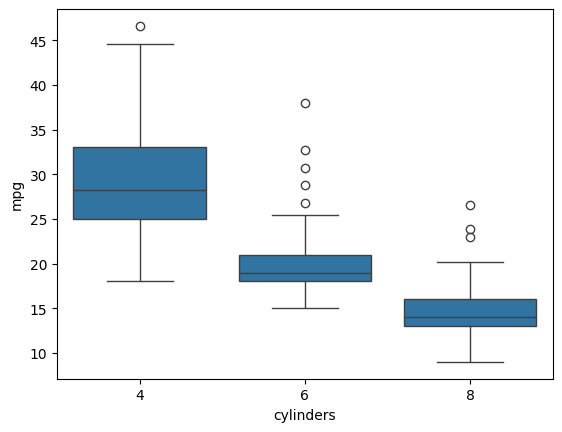

In [135]:
sns.boxplot(data=mpg, x='cylinders', y='mpg')

<Axes: xlabel='horsepower', ylabel='mpg'>

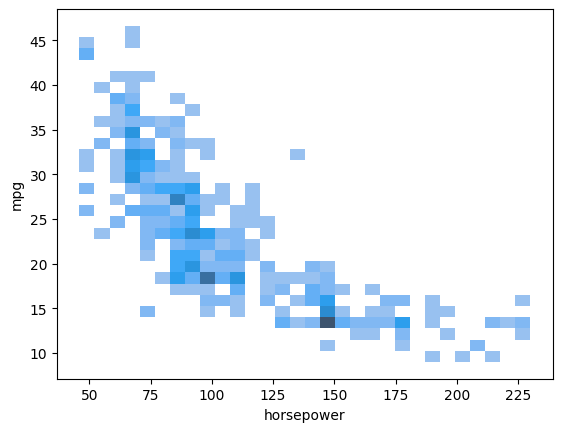

In [136]:
sns.histplot(data=mpg, x='horsepower', y='mpg', bins=30)

<Axes: xlabel='weight', ylabel='mpg'>

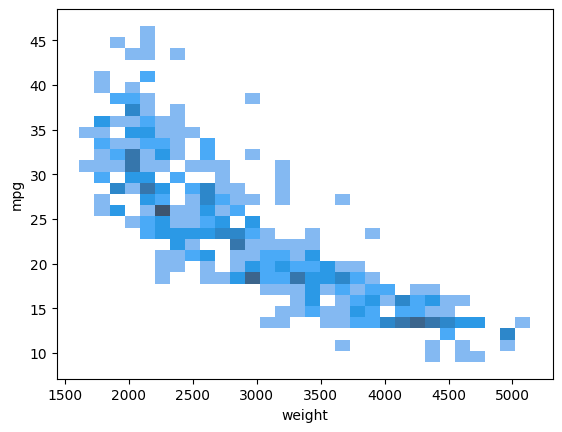

In [137]:
sns.histplot(data=mpg, x='weight', y='mpg', bins=30)

<Axes: xlabel='model_year', ylabel='mpg'>

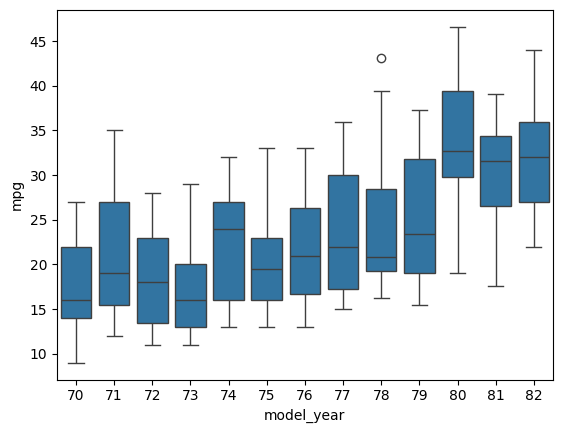

In [138]:
sns.boxplot(data=mpg, x='model_year', y='mpg')

# 0d)

Jag väljer att droppa båda kategoriska kolumner då ursprung och namn inte spelar någon roll för bränsleförbrukning

In [139]:
mpg = mpg.drop(columns=['origin', 'name'])

# 1)

In [ ]:
X = mpg[['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']]
y = mpg['mpg']

X_train, X_test, y_train, y_test = tts(X, y, test_size=.2, random_state=42)

print(f'X_train shape: {X_train.shape}\nX_test shape: {X_test.shape}\ny_train shape: {y_train.shape}\ny_test shape: {y_test.shape}')

X_train shape: (312, 6)
X_test shape: (79, 6)
y_train shape: (312,)
y_test shape: (79,)


# 2)

In [ ]:
model = linreg()

def train_and_evaluate(X_train, X_test, y_train, y_test, model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    MAE = mean_absolute_error(y_test, y_pred)
    MSE = mean_squared_error(y_test, y_pred)
    RMSE = np.sqrt(MSE)
    return MAE, MSE, RMSE

test1 = train_and_evaluate(X_train, X_test, y_train, y_test, model)
test1

(2.9710208196514705, 14.380742795690047, np.float64(3.7921949838701656))

# 3)

In [ ]:
results = []

mae, mse, rmse = train_and_evaluate(X_train, X_test, y_train, y_test, linreg())
results.append({'Model': 'Linear Regression', 'MAE': mae, 'MSE': mse, 'RMSE': rmse})

scaler = StandardScaler()

S_X_train = scaler.fit_transform(X_train)
S_X_test = scaler.transform(X_test)

S_mae, S_mse, S_rmse = train_and_evaluate(S_X_train, S_X_test, y_train, y_test, linreg())
results.append({'Model': 'LinReg with scaled data', 'MAE': S_mae, 'MSE': S_mse, 'RMSE': S_rmse})

poly1 = PolynomialFeatures(degree=1)

P1_X_train = poly1.fit_transform(X_train)
P1_X_test = poly1.transform(X_test)

P1_mae, P1_mse, P1_rmse = train_and_evaluate(P1_X_train, P1_X_test, y_train, y_test, linreg())
results.append({'Model': 'PolyReg 1', 'MAE': P1_mae, 'MSE': P1_mse, 'RMSE': P1_rmse})

poly2 = PolynomialFeatures(degree=2)

P2_X_train = poly2.fit_transform(X_train)
P2_X_test = poly2.transform(X_test)

P2_mae, P2_mse, P2_rmse = train_and_evaluate(P2_X_train, P2_X_test, y_train, y_test, linreg())
results.append({'Model': 'PolyReg 2', 'MAE': P2_mae, 'MSE': P2_mse, 'RMSE': P2_rmse})

poly3 = PolynomialFeatures(degree=3)

P3_X_train = poly3.fit_transform(X_train)
P3_X_test = poly3.transform(X_test)

P3_mae, P3_mse, P3_rmse = train_and_evaluate(P3_X_train, P3_X_test, y_train, y_test, linreg())
results.append({'Model': 'PolyReg 3', 'MAE': P3_mae, 'MSE': P3_mse, 'RMSE': P3_rmse})

In [ ]:
results_pipeline = []

mae, mse, rmse = train_and_evaluate(X_train, X_test, y_train, y_test, linreg())
results_pipeline.append({'Model': 'Linear Regression', 'MAE': mae, 'MSE': mse, 'RMSE': rmse})

scaled_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', linreg())
])
S_mae, S_mse, S_rmse = train_and_evaluate(X_train, X_test, y_train, y_test, scaled_pipeline)
results_pipeline.append({'Model': 'LinReg with scaled data', 'MAE': S_mae, 'MSE': S_mse, 'RMSE': S_rmse})

poly1_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=1)),
    ('model', linreg())
])
P1_mae, P1_mse, P1_rmse = train_and_evaluate(X_train, X_test, y_train, y_test, poly1_pipeline)
results_pipeline.append({'Model': 'PolyReg 1', 'MAE': P1_mae, 'MSE': P1_mse, 'RMSE': P1_rmse})

poly2_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('model', linreg())
])
P2_mae, P2_mse, P2_rmse = train_and_evaluate(X_train, X_test, y_train, y_test, poly2_pipeline)
results_pipeline.append({'Model': 'PolyReg 2', 'MAE': P2_mae, 'MSE': P2_mse, 'RMSE': P2_rmse})

poly3_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=3)),
    ('model', linreg())
])
P3_mae, P3_mse, P3_rmse = train_and_evaluate(X_train, X_test, y_train, y_test, poly3_pipeline)
results_pipeline.append({'Model': 'PolyReg 3', 'MAE': P3_mae, 'MSE': P3_mse, 'RMSE': P3_rmse})

pd.DataFrame(results_pipeline)

,Model,MAE,MSE,RMSE
0,Linear Regression,2.971021,14.380743,3.792195
1,LinReg with scaled data,2.971021,14.380743,3.792195
2,PolyReg 1,2.971021,14.380743,3.792195
3,PolyReg 2,2.198636,8.998590,2.999765
4,PolyReg 3,2.372076,10.597404,3.255365


Polynomiell regression med grad 2 presterade bäst

# 4)

In [144]:
print(P2_X_train.shape)
print(P3_X_train.shape)

(312, 28)
(312, 84)


P.g.a. låg sample size relativt till antal features det tränas mot presterar polynomiell regression med grad 3 sämre än med grad 2 som är inom tumregeln om att features bör vara minst 1/10 av sample size för att vara träffsäkert

In [ ]:
def cross_val_evaluate(pipeline, X, y, cv=5):
    mae = -cross_val_score(pipeline, X, y, cv=cv, scoring='neg_mean_absolute_error').mean()
    mse = -cross_val_score(pipeline, X, y, cv=cv, scoring='neg_mean_squared_error').mean()
    rmse = -cross_val_score(pipeline, X, y, cv=cv, scoring='neg_root_mean_squared_error').mean()
    return mae, mse, rmse

P2_mae_cv, P2_mse_cv, P2_rmse_cv = cross_val_evaluate(poly2_pipeline, X, y, cv=5)
results.append({'Model': 'PolyReg 2 cv', 'MAE': P2_mae_cv, 'MSE': P2_mse_cv, 'RMSE': P2_rmse_cv})
P3_mae_cv, P3_mse_cv, P3_rmse_cv = cross_val_evaluate(poly3_pipeline, X, y, cv=5)
results.append({'Model': 'PolyReg 3 cv', 'MAE': P3_mae_cv, 'MSE': P3_mse_cv, 'RMSE': P3_rmse_cv})

results = pd.DataFrame(results)

results

,Model,MAE,MSE,RMSE
0,Linear Regression,2.971021,14.380743,3.792195
1,LinReg with scaled data,2.971021,14.380743,3.792195
2,PolyReg 1,2.971021,14.380743,3.792195
3,PolyReg 2,2.198636,8.998590,2.999765
4,PolyReg 3,2.372076,10.597404,3.255365
5,PolyReg 2 cv,2.475150,10.889306,3.152758
6,PolyReg 3 cv,3.277471,31.325790,5.054631


Här ser vi att även med cross validation är polynomiell regression med grad 3 avsevärt sämre än grad 2 och vi får även en mer träffsäker bild av grad 2 efter att ha testat med 5 folds p.g.a. slumpmässigheten i cross validation eliminerar eventuell bias från endast en split

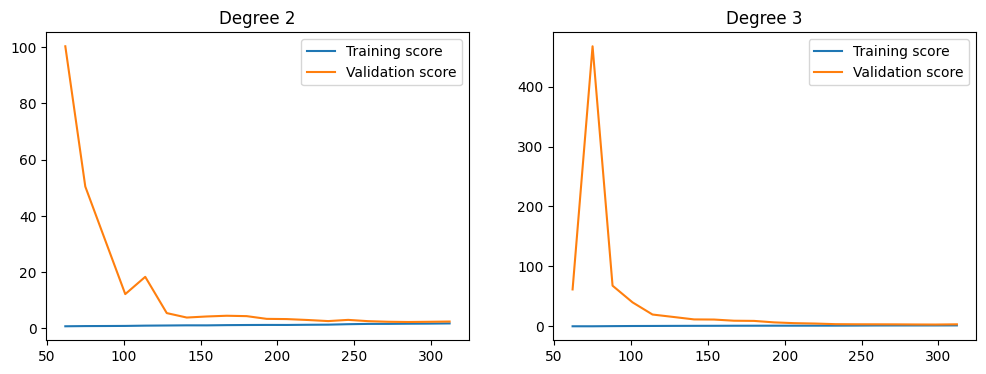

In [ ]:
train_sizes2, train_scores2, val_scores2 = learning_curve(poly2_pipeline, X, y, train_sizes=np.linspace(0.2, 1.0, 20), scoring='neg_mean_absolute_error')
train_sizes3, train_scores3, val_scores3 = learning_curve(poly3_pipeline, X, y, train_sizes=np.linspace(0.2, 1.0, 20), scoring='neg_mean_absolute_error')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_sizes2, -train_scores2.mean(axis=1), label='Training score')
ax1.plot(train_sizes2, -val_scores2.mean(axis=1), label='Validation score')
ax1.set_title('Degree 2')
ax1.legend()

ax2.plot(train_sizes3, -train_scores3.mean(axis=1), label='Training score')
ax2.plot(train_sizes3, -val_scores3.mean(axis=1), label='Validation score')
ax2.set_title('Degree 3')
ax2.legend()

Med dessa plots kan vi se att båda två är ostabila på låga sample size men att grad 2 fortfarande är markant bättre även om grad 3 förändras i större takt när sample size ökar